In [2]:
import scanpy as sc
import os
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import decoupler as dc
sc.settings.verbosity=0 # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.n_jobs=4
sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(15,15))
plt.rcParams['pdf.fonttype'] = 42
%matplotlib inline




# t cell genes of interest

In [3]:
def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_lesional.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST = [gene for gene in LIST if gene in adata_lesional.var_names]
    return LIST

t_dict = {
    "Naive": ["CCR7", "SELL",# "CD40LG"
             ],
    'Treg': ['FOXP3', 'TIGIT', 'CTLA4','LRRC32'],
    'CD8 Tissue-residency\n markers': ["CD8A", 'ITGAE'],
    'Type 2-associated': ['IL22', 'IL13'],
    "Other": ['GZMB',],
    'Cycling': ['MKI67', 'TOP2A']
}

# extrinsic

In [4]:
#adata_lesional=sc.read_h5ad('/nfs/team361/ls34/data/adata_xenium5k_akbar_24jan_4samples.h5ad')
adata_lesional=sc.read_h5ad('/nfs/team361/ls34/data/adata_xenium5k_akbar_24dec_selectsamples.h5ad')
    #'/nfs/team361/ls34/inflow/final_adatas/adata_xenium5k_akbar_24jan_4samples.h5ad')

adata_lesional.obs.info_id.value_counts()

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


info_id
BK30_Day 14                   32270
BK23_Lesional Baseline        28744
BK22_Lesional Baseline        22181
BK23_Non-lesional Baseline    19220
BK30_Lesional Baseline        18561
BK39_Non-lesional Baseline    17993
BK18_Lesional Baseline        17833
BK39_Lesional Baseline        17420
BK27_Non-lesional Baseline    16589
BK21_Lesional Baseline        15564
Name: count, dtype: int64

In [5]:
adata_lesional.obs.sample_id.value_counts()

sample_id
output-XETG00155__0043607__BK30-SKI-28-FO-1-S3-4__20241010__133127                            32270
output-XETG00272__0041416__BK23-SKI-27-FO-1-S6-C2__20241107__113553                           28744
output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553                          22181
output-XETG00272__0041416__BK23-SKI-27-FO-2-S6-D1_BK23-SKI-27-FO-4-S6-E1__20241107__113553    19220
output-XETG00155__0043607__BK30-SKI-27-FO-1-2-S3__20241010__133127                            18560
output-XETG00155__0043607__BK39-SKI-27-FO-2-S3-4__20241010__133127                            17993
output-XETG00272__0027131__Region_7__20240628__124459                                         17833
output-XETG00155__0043607__BK39-SKI-27-FO-1-S3__20241010__133127                              17420
output-XETG00272__0027175__Region_2__20240628__124459                                         16589
output-XETG00272__0027175__Region_7__20240628__124459                                     

In [6]:
adata_t=sc.read_h5ad('/nfs/team361/ls34/inflow/final_adatas/adata_tcells.h5ad')
adata_t

AnnData object with n_obs × n_vars = 17064 × 1032
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', 'Site_status', 'info_id', 'sample', 'niche_name', 'lvl1', 'lvl0', 'veryfine_celltypes_new5', 'veryfine_celltypes_new5_incprolif', 'veryfine_celltypes', 'fine_celltypes_new', 'mod_celltypes_new', 'broad_celltypes_new', 'Site_status_binary', 'fine_celltypes', 'broad_celltypes', 'n_counts', 'n_genes', 'inflow_cell_type', 'inflow_biological_batch_ID', 'inflow_slice_ID', 'inflow_signaling_activity', 'leiden_res0.8', 'leiden_res0.5', 'NICHE_NAMES', 'spatial_niche', 'baseline_severity', 'leiden_res0.1', 't_cellsubtypes'
    uns: 'NICHE_NAMES_colors', 'Site_status_binary_colors', 'broad_cellt

In [7]:
mapping_dict2 = adata_t.obs["t_cellsubtypes"].to_dict()
adata_lesional.obs["t_cellsubtypes"] = adata_lesional.obs.index.map(mapping_dict2).fillna("Other")
adata_lesional.obs["t_cellsubtypes"].value_counts()


t_cellsubtypes
Other          189311
Dermis          14741
Superficial      2323
Name: count, dtype: int64

In [8]:
adata_lesional=adata_lesional[adata_lesional.obs["t_cellsubtypes"]!="Other"]

In [9]:
# adata_lesional

View of AnnData object with n_obs × n_vars = 17064 × 5000
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', 'Site_status', 'info_id', 'sample', 'niche_name', 'lvl1', 'lvl0', 'veryfine_celltypes_new5', 'veryfine_celltypes_new5_incprolif', 'veryfine_celltypes', 'fine_celltypes_new', 'mod_celltypes_new', 'broad_celltypes_new', 'Site_status_binary', 'fine_celltypes', 'broad_celltypes', 't_cellsubtypes'
    var: 'SYMBOL'
    uns: 'broad_celltypes_colors', 'de_leiden', 'fine_celltypes_colors', 'fine_celltypes_new_colors', 'leiden_res1', 'leiden_res2', 'log1p', 'lvl3_annotation_colors', 'lvl4_annotation_colors', 'lvl5_annotation_colors', 'mod_celltypes_new_colors', 'neighbor_20', 'new_anno

In [22]:
# adata_t.X = adata_t.obsm["inflow_Xspl"]

In [10]:
def remove_markers2(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_t.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST = [gene for gene in LIST if gene in adata_t.var_names]
    return LIST


In [11]:
# fig = sc.pl.DotPlot(
#     adata_t, 
#     remove_markers2(t_dict),
#     groupby='t_cellsubtypes',
#     vmax=1,
#     cmap="Reds"
# )
# fig.style(cmap='Reds', color_on='square', dot_edge_color='black', dot_edge_lw=1, grid=True)
# fig.show()

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


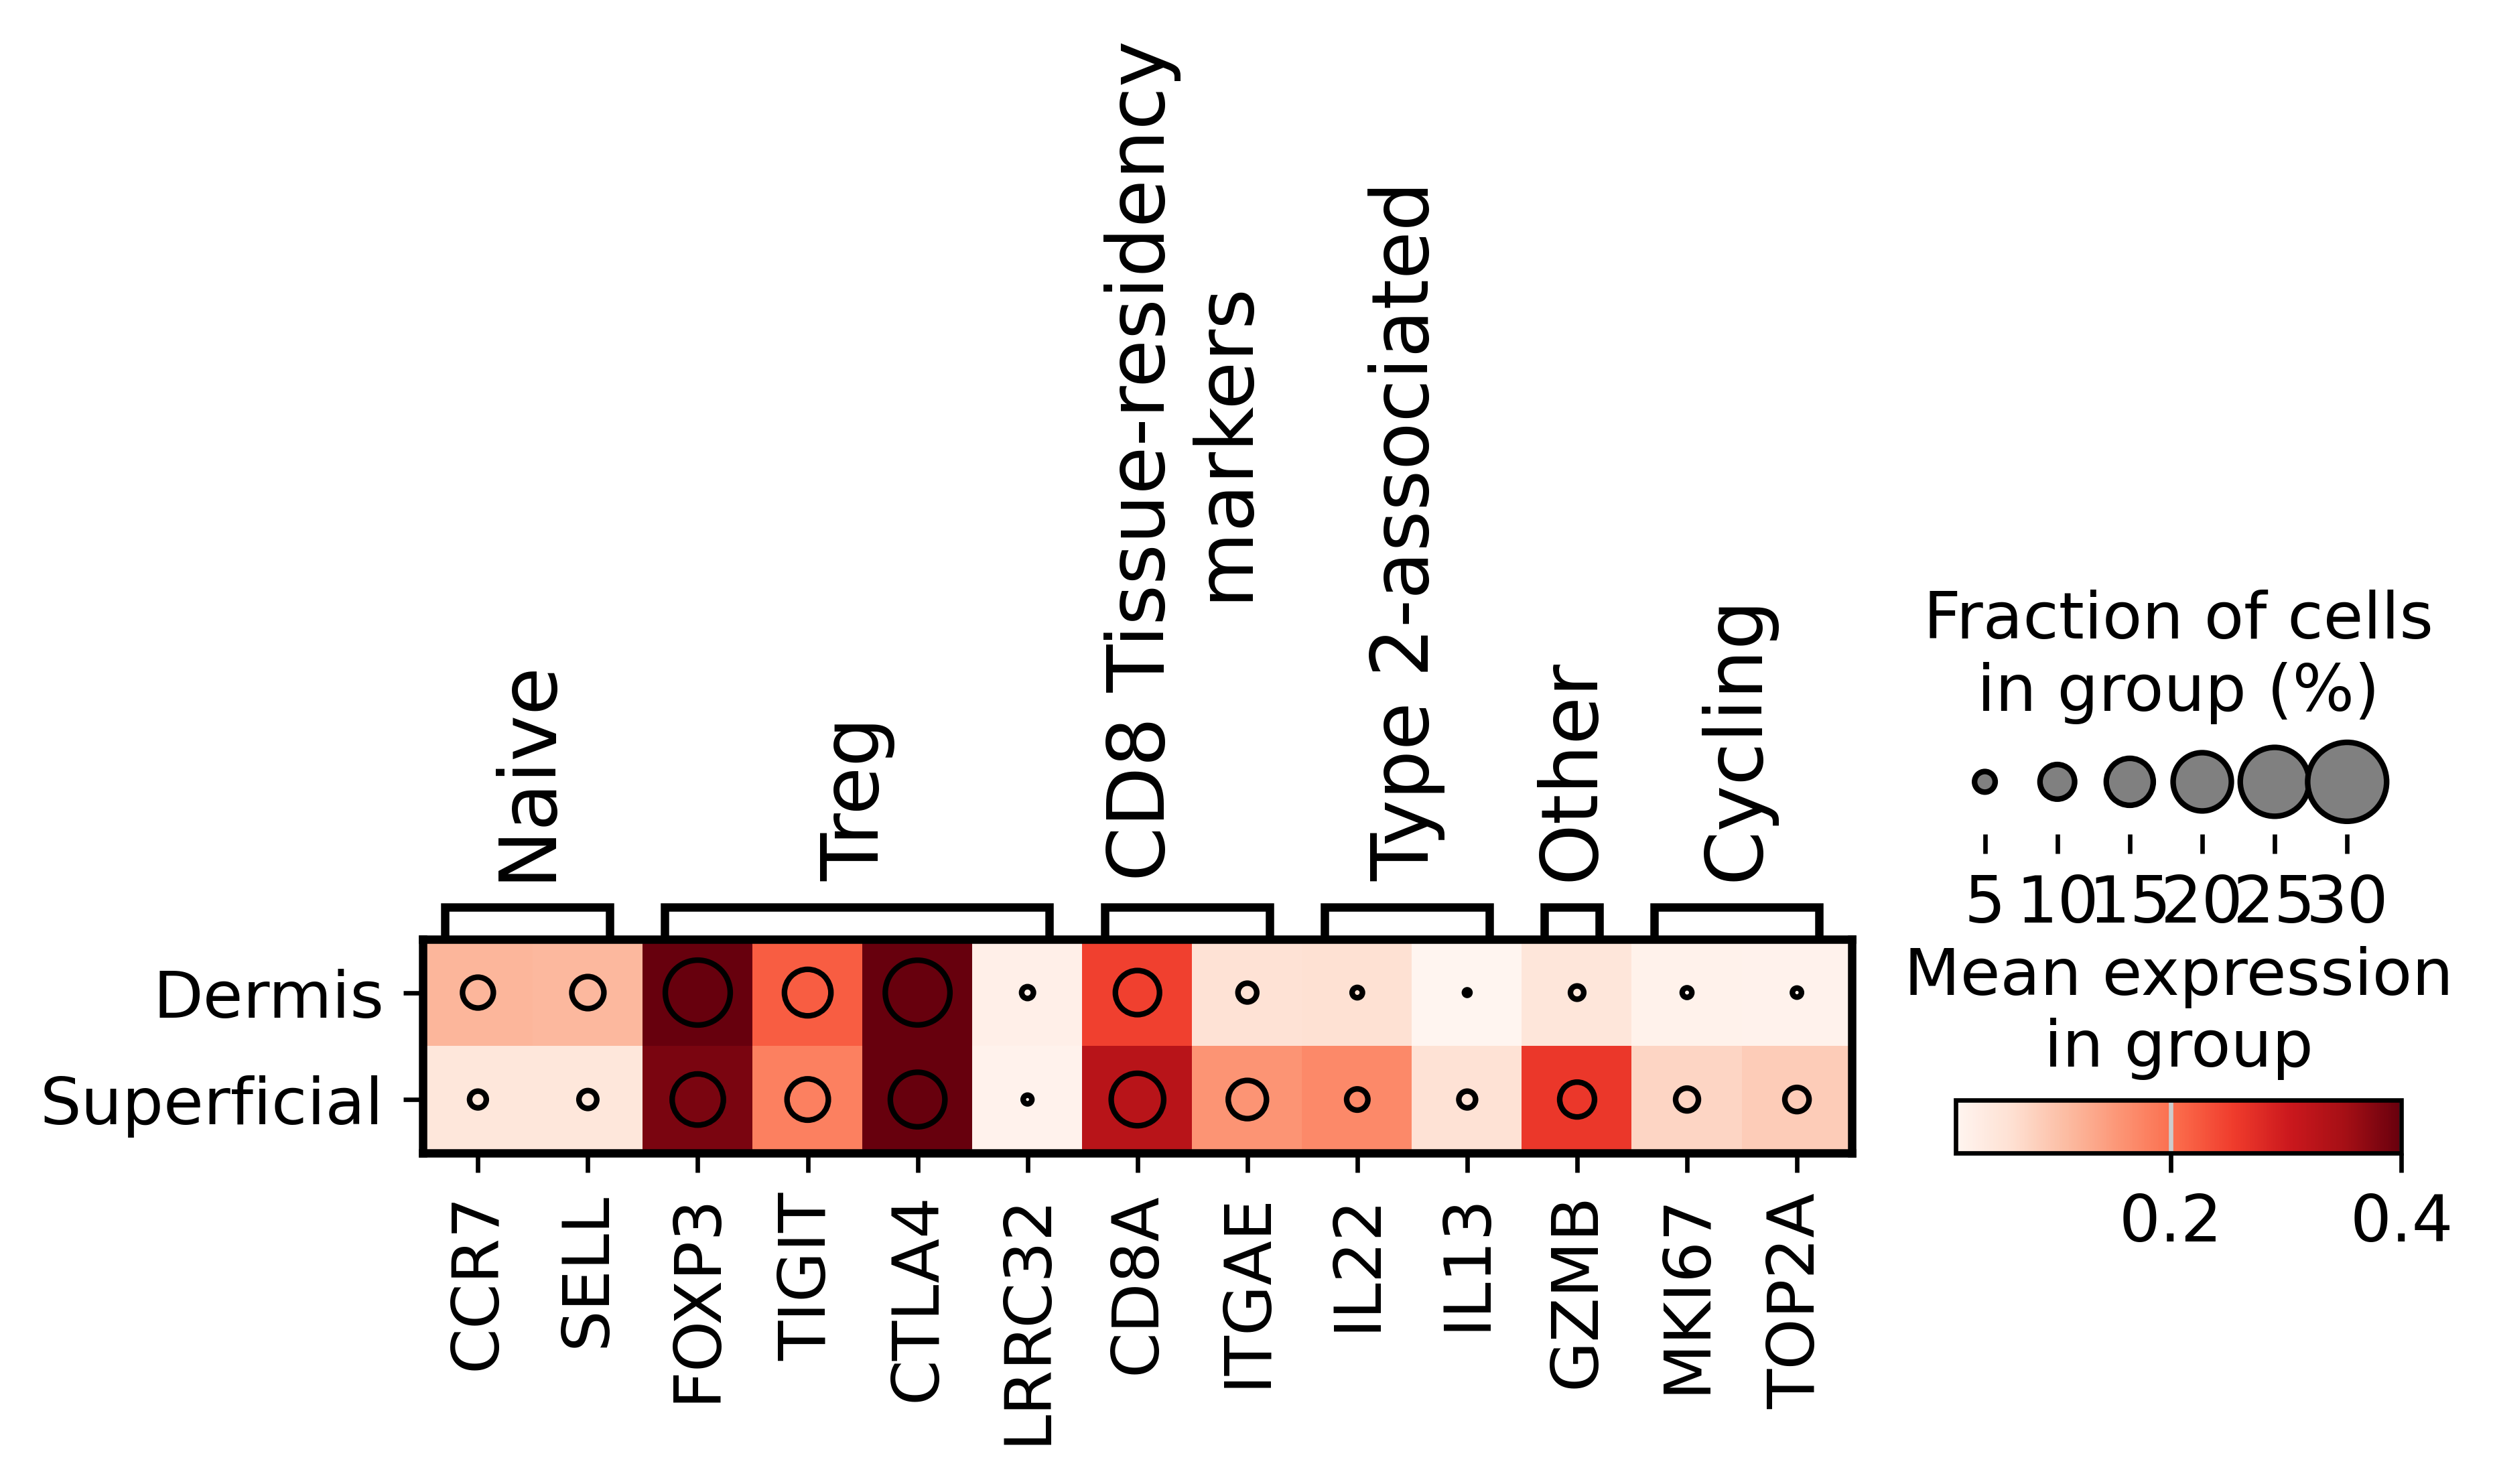

In [12]:
fig = sc.pl.DotPlot(
    adata_lesional, 
    remove_markers(t_dict),
    groupby='t_cellsubtypes',
    vmax=0.4,
    cmap="Reds"
)
fig.style(cmap='Reds', color_on='square', dot_edge_color='black', dot_edge_lw=1, grid=True)
fig.show()

In [14]:
# adata_lesional.obs["Site_status"].value_counts()

Site_status
Lesional       14089
Nonlesional     2975
Name: count, dtype: int64

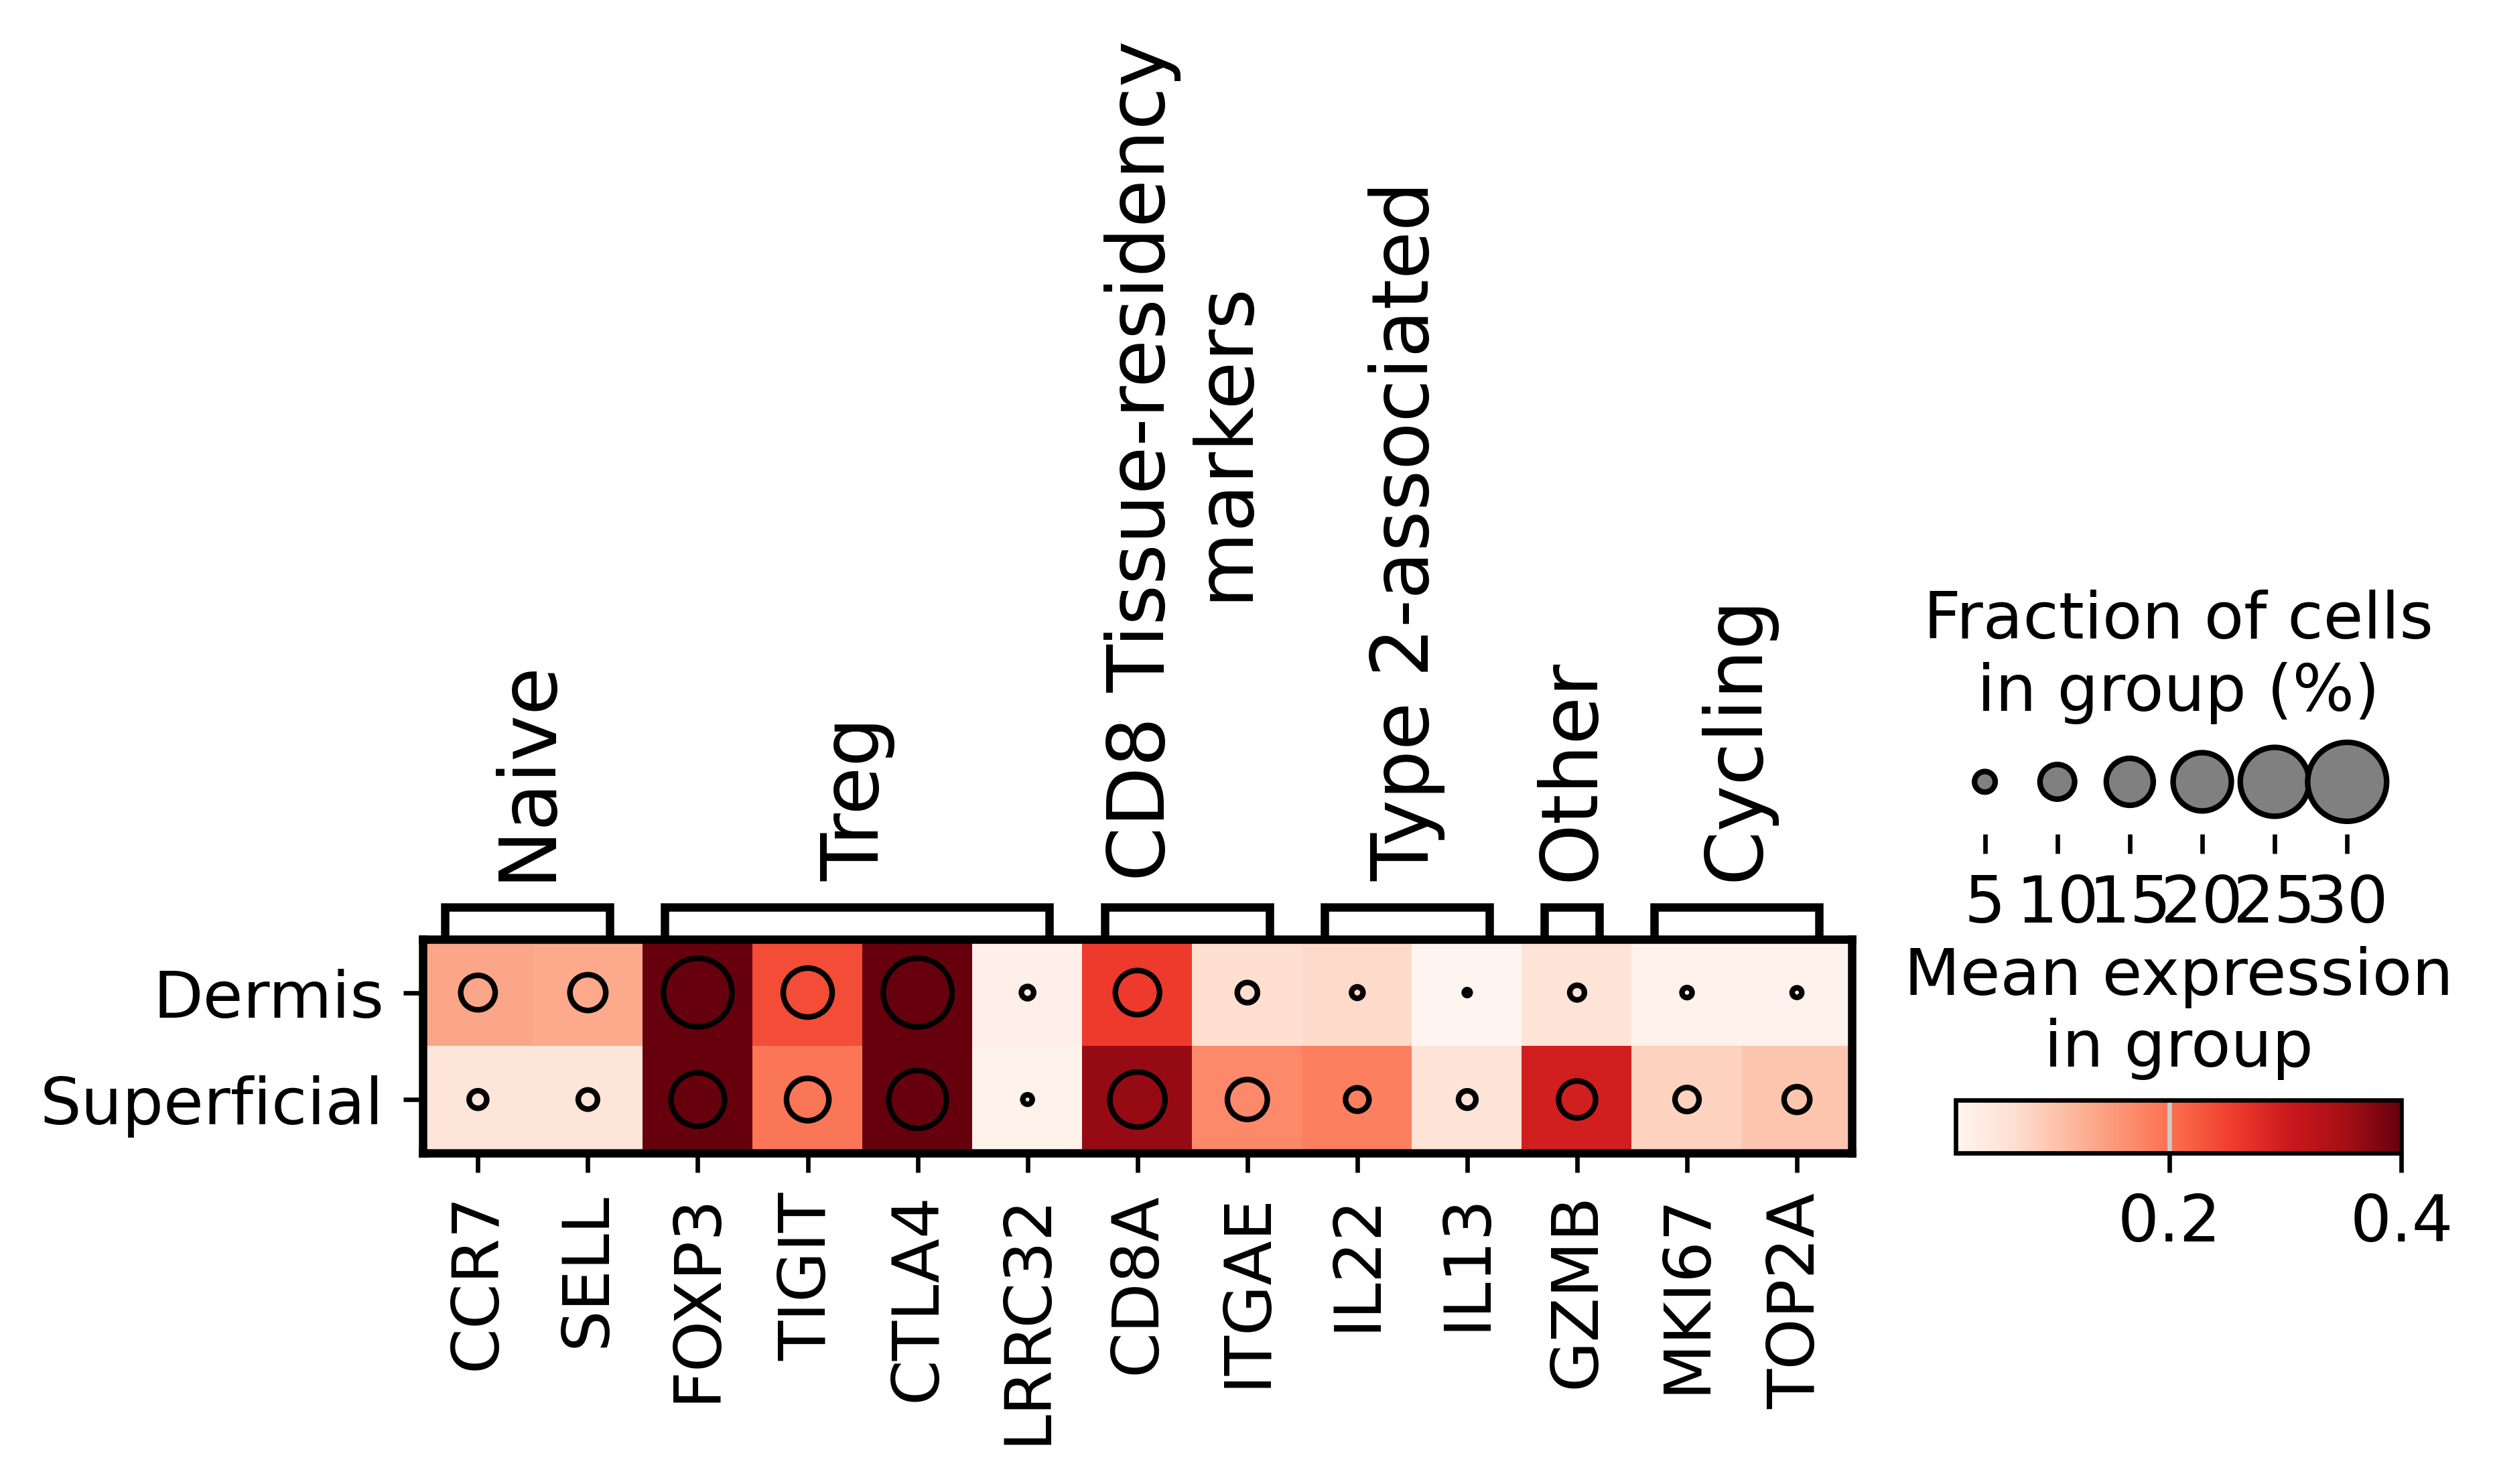

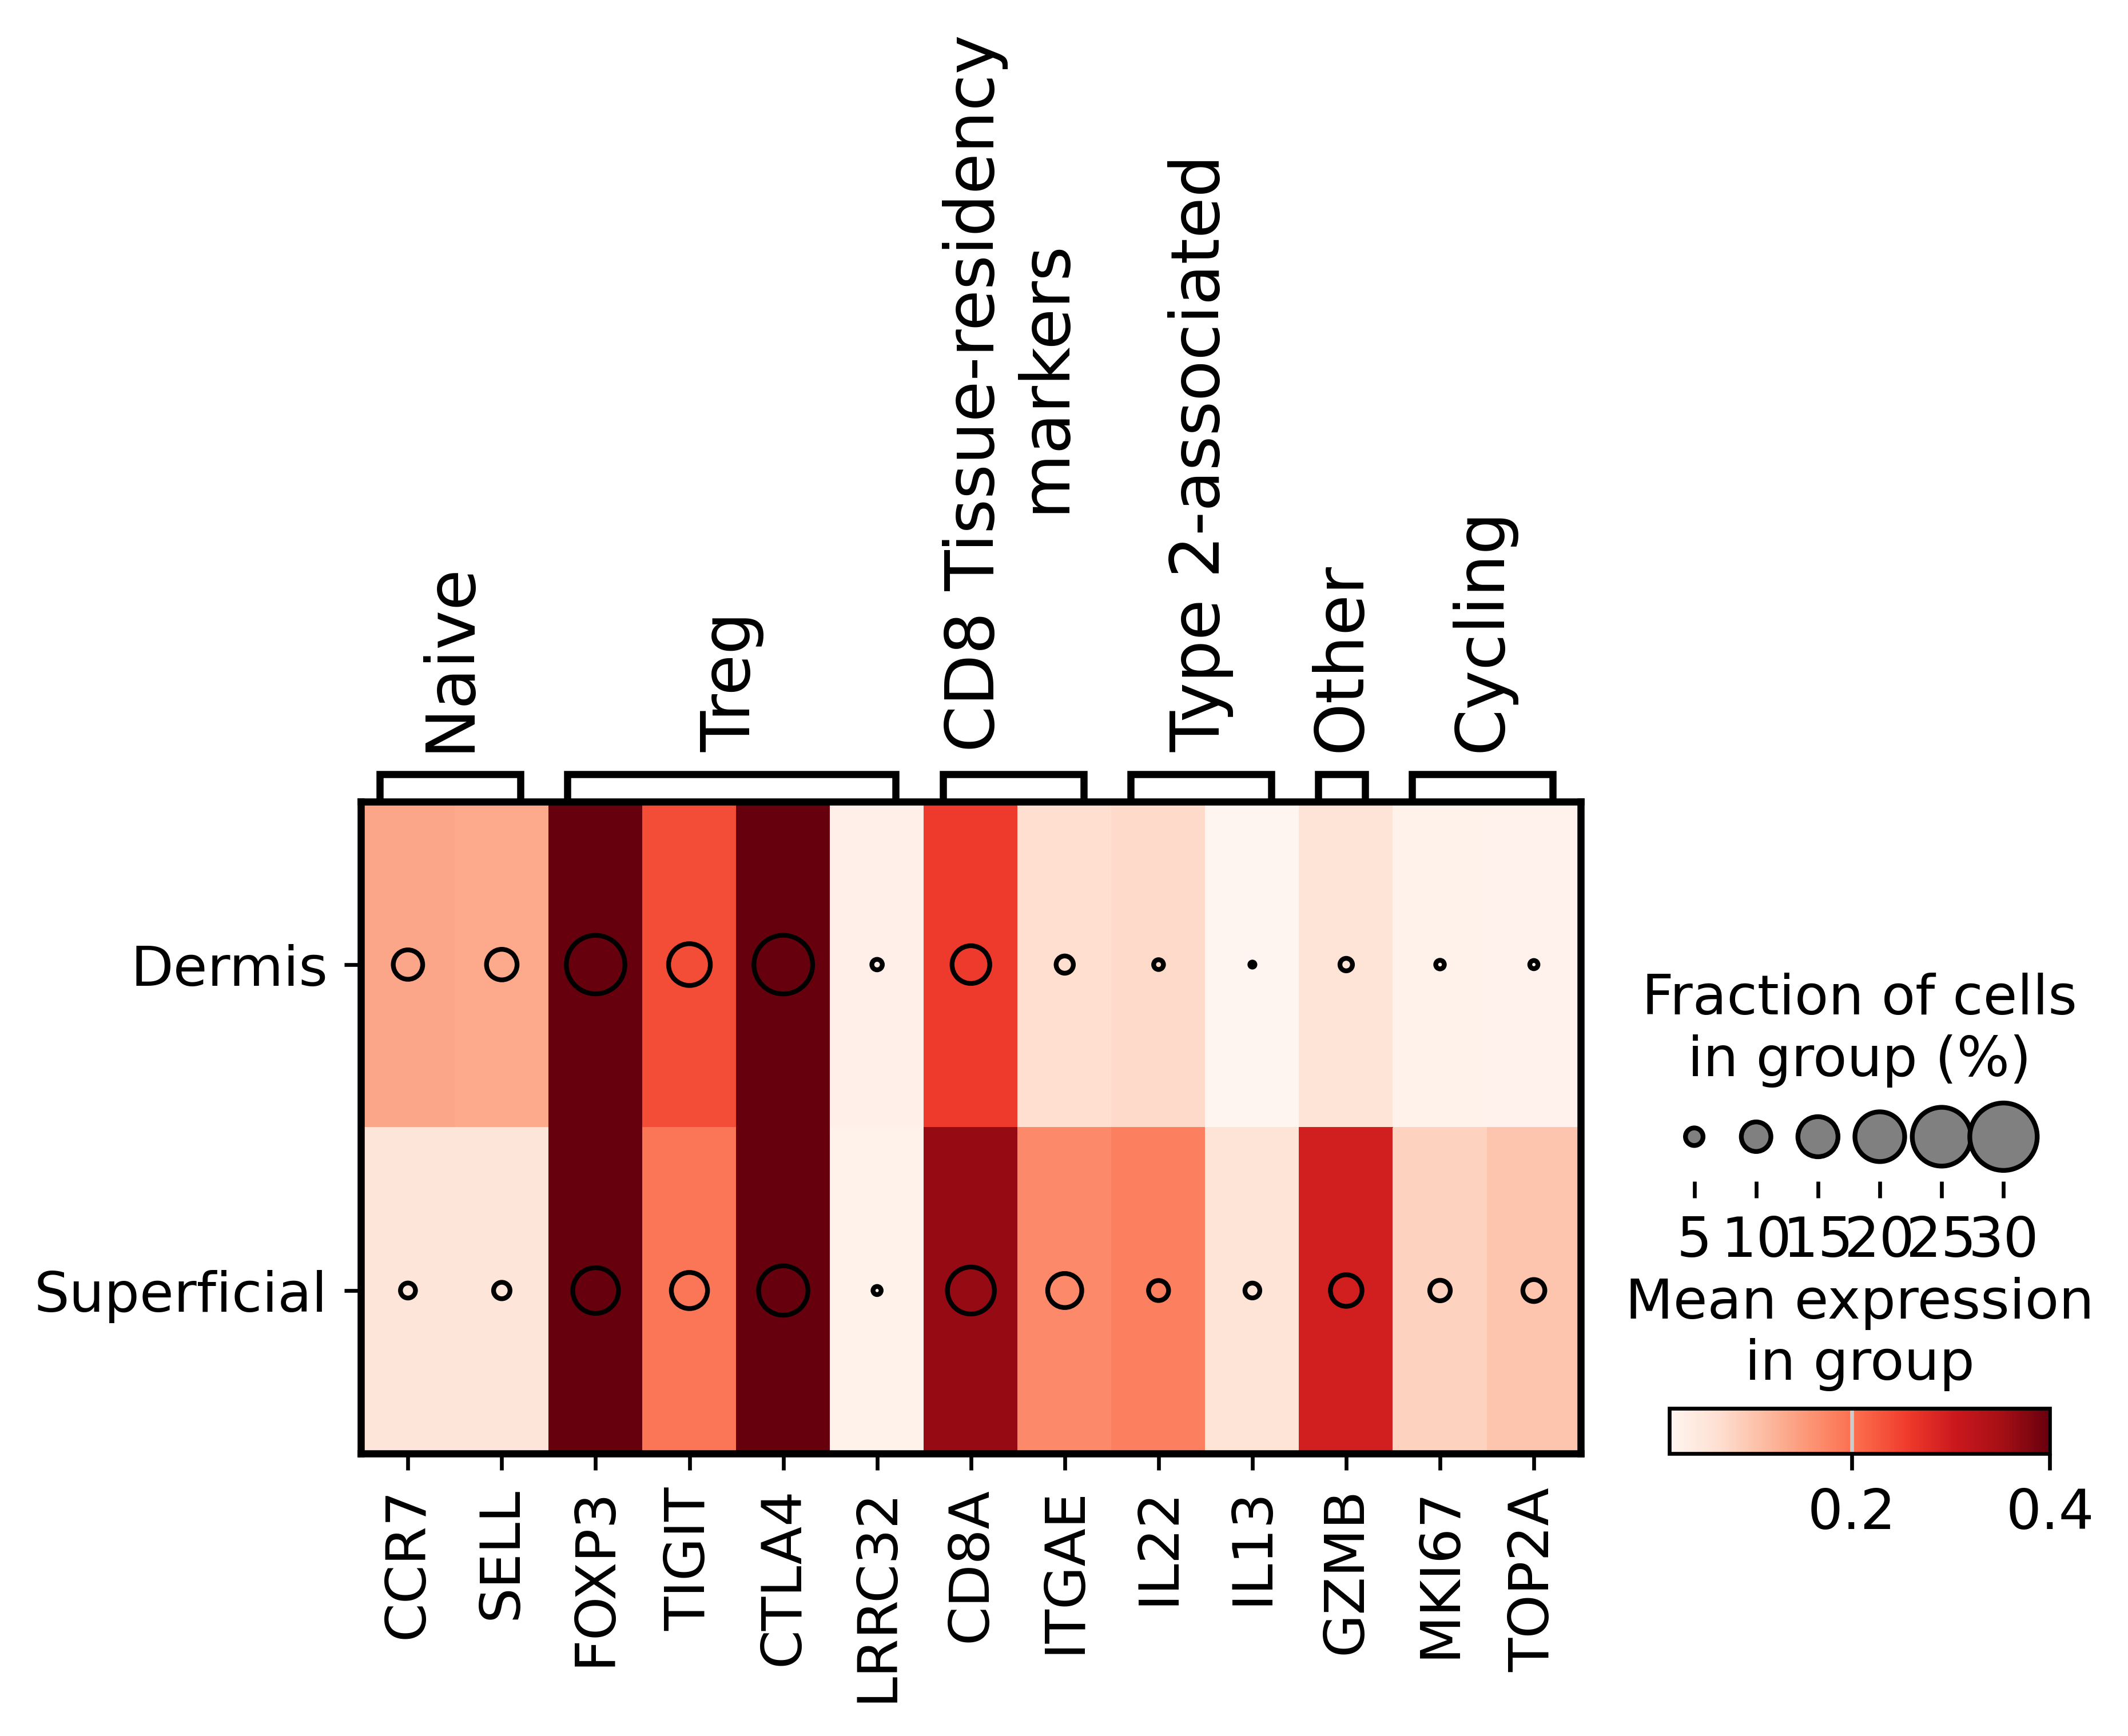

In [15]:
fig = sc.pl.DotPlot(
    adata_lesional[adata_lesional.obs["Site_status"]=="Lesional"], 
    remove_markers(t_dict),
    groupby='t_cellsubtypes',
    vmax=0.4,
    cmap="Reds"
)
fig.style(cmap='Reds', color_on='square', dot_edge_color='black', dot_edge_lw=1, grid=True)
fig.savefig("figures/eczema_j.pdf", bbox_inches='tight')
fig.show()

# intrinsic

In [16]:
adata_intrinsic =sc.read_h5ad('/nfs/team361/ls34/inflow/final_adatas/adata_tcells_intrinsic.h5ad')
adata_all_genes=adata_lesional

mapping_dict = adata_intrinsic.obs["t_intrinsic"].to_dict()

adata_all_genes.obs["t_intrinsic"] = adata_all_genes.obs.index.map(mapping_dict).fillna("Other")

# mapping_dict = adata_intrinsic.obs["t_intrinsic2"].to_dict()
# adata_all_genes.obs["t_intrinsic2"] = adata_all_genes.obs.index.map(mapping_dict).fillna("Other")

# adata_all_genes.obs["t_intrinsic2"].value_counts()



In [17]:
adata_all_genes= adata_all_genes[adata_all_genes.obs["t_intrinsic"]!="Other"]

In [18]:
adata_all_genes.obs["t_intrinsic"].unique()


array(['Naive', 'T', 'Treg'], dtype=object)

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


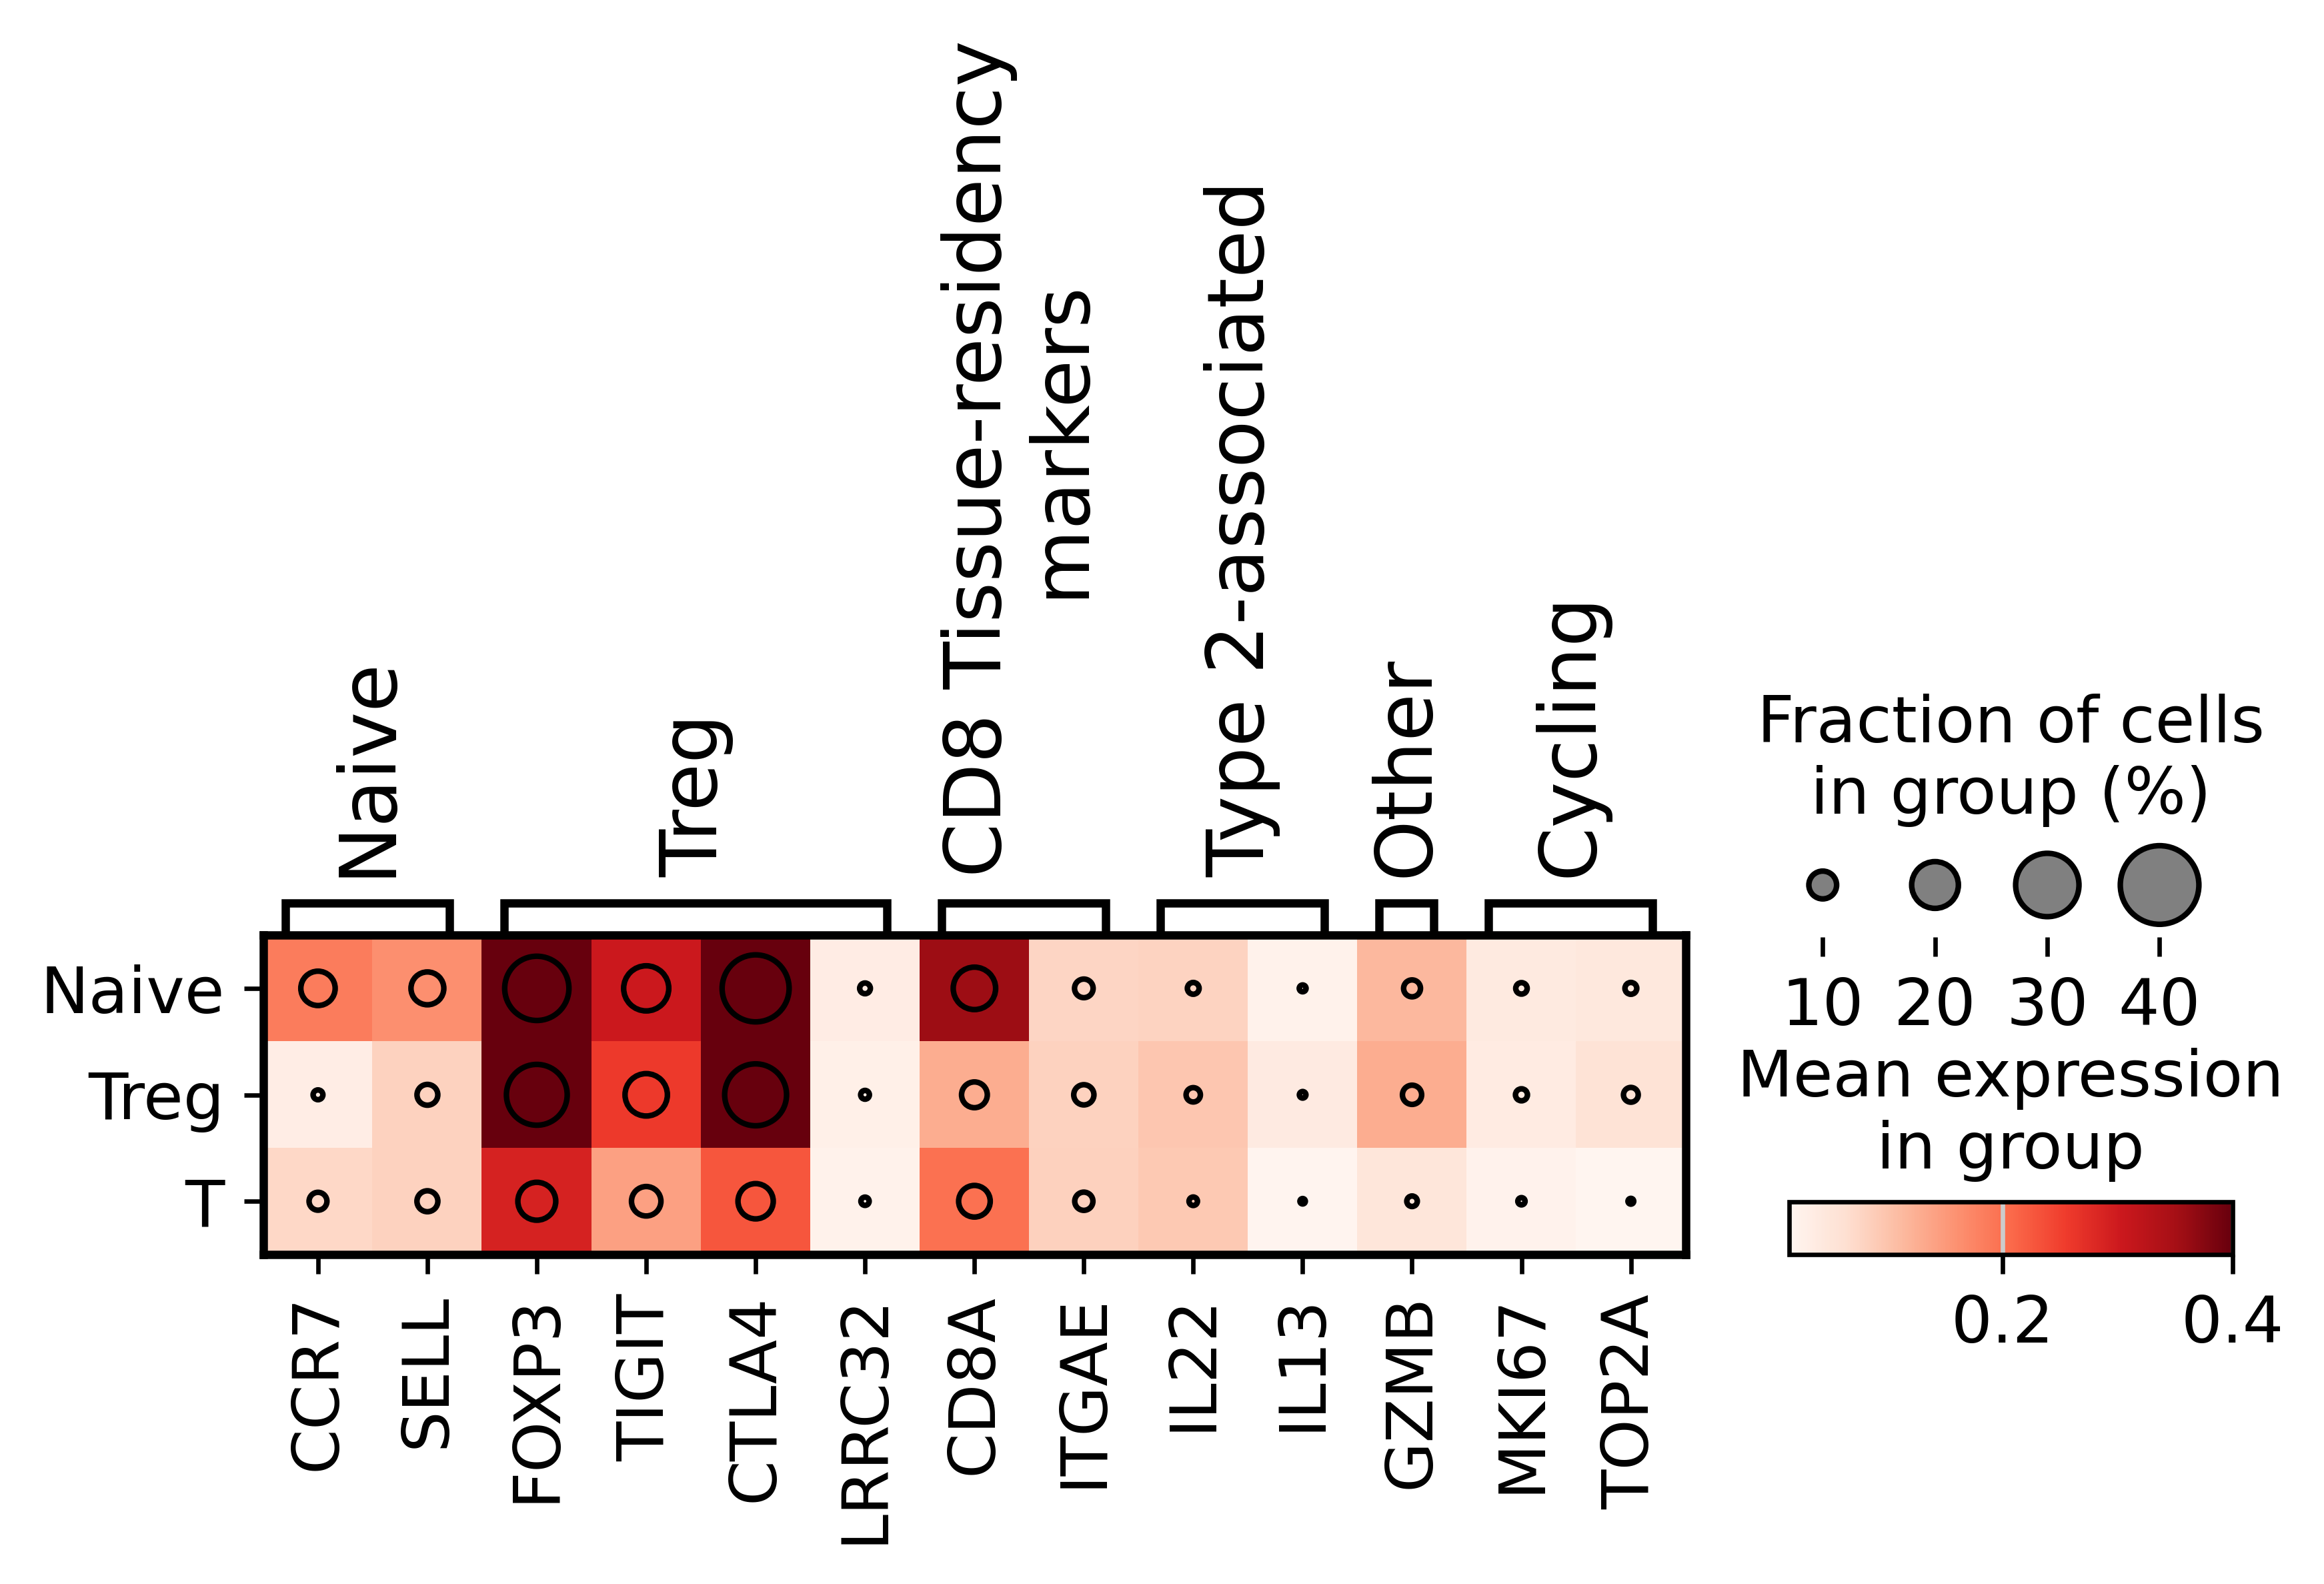

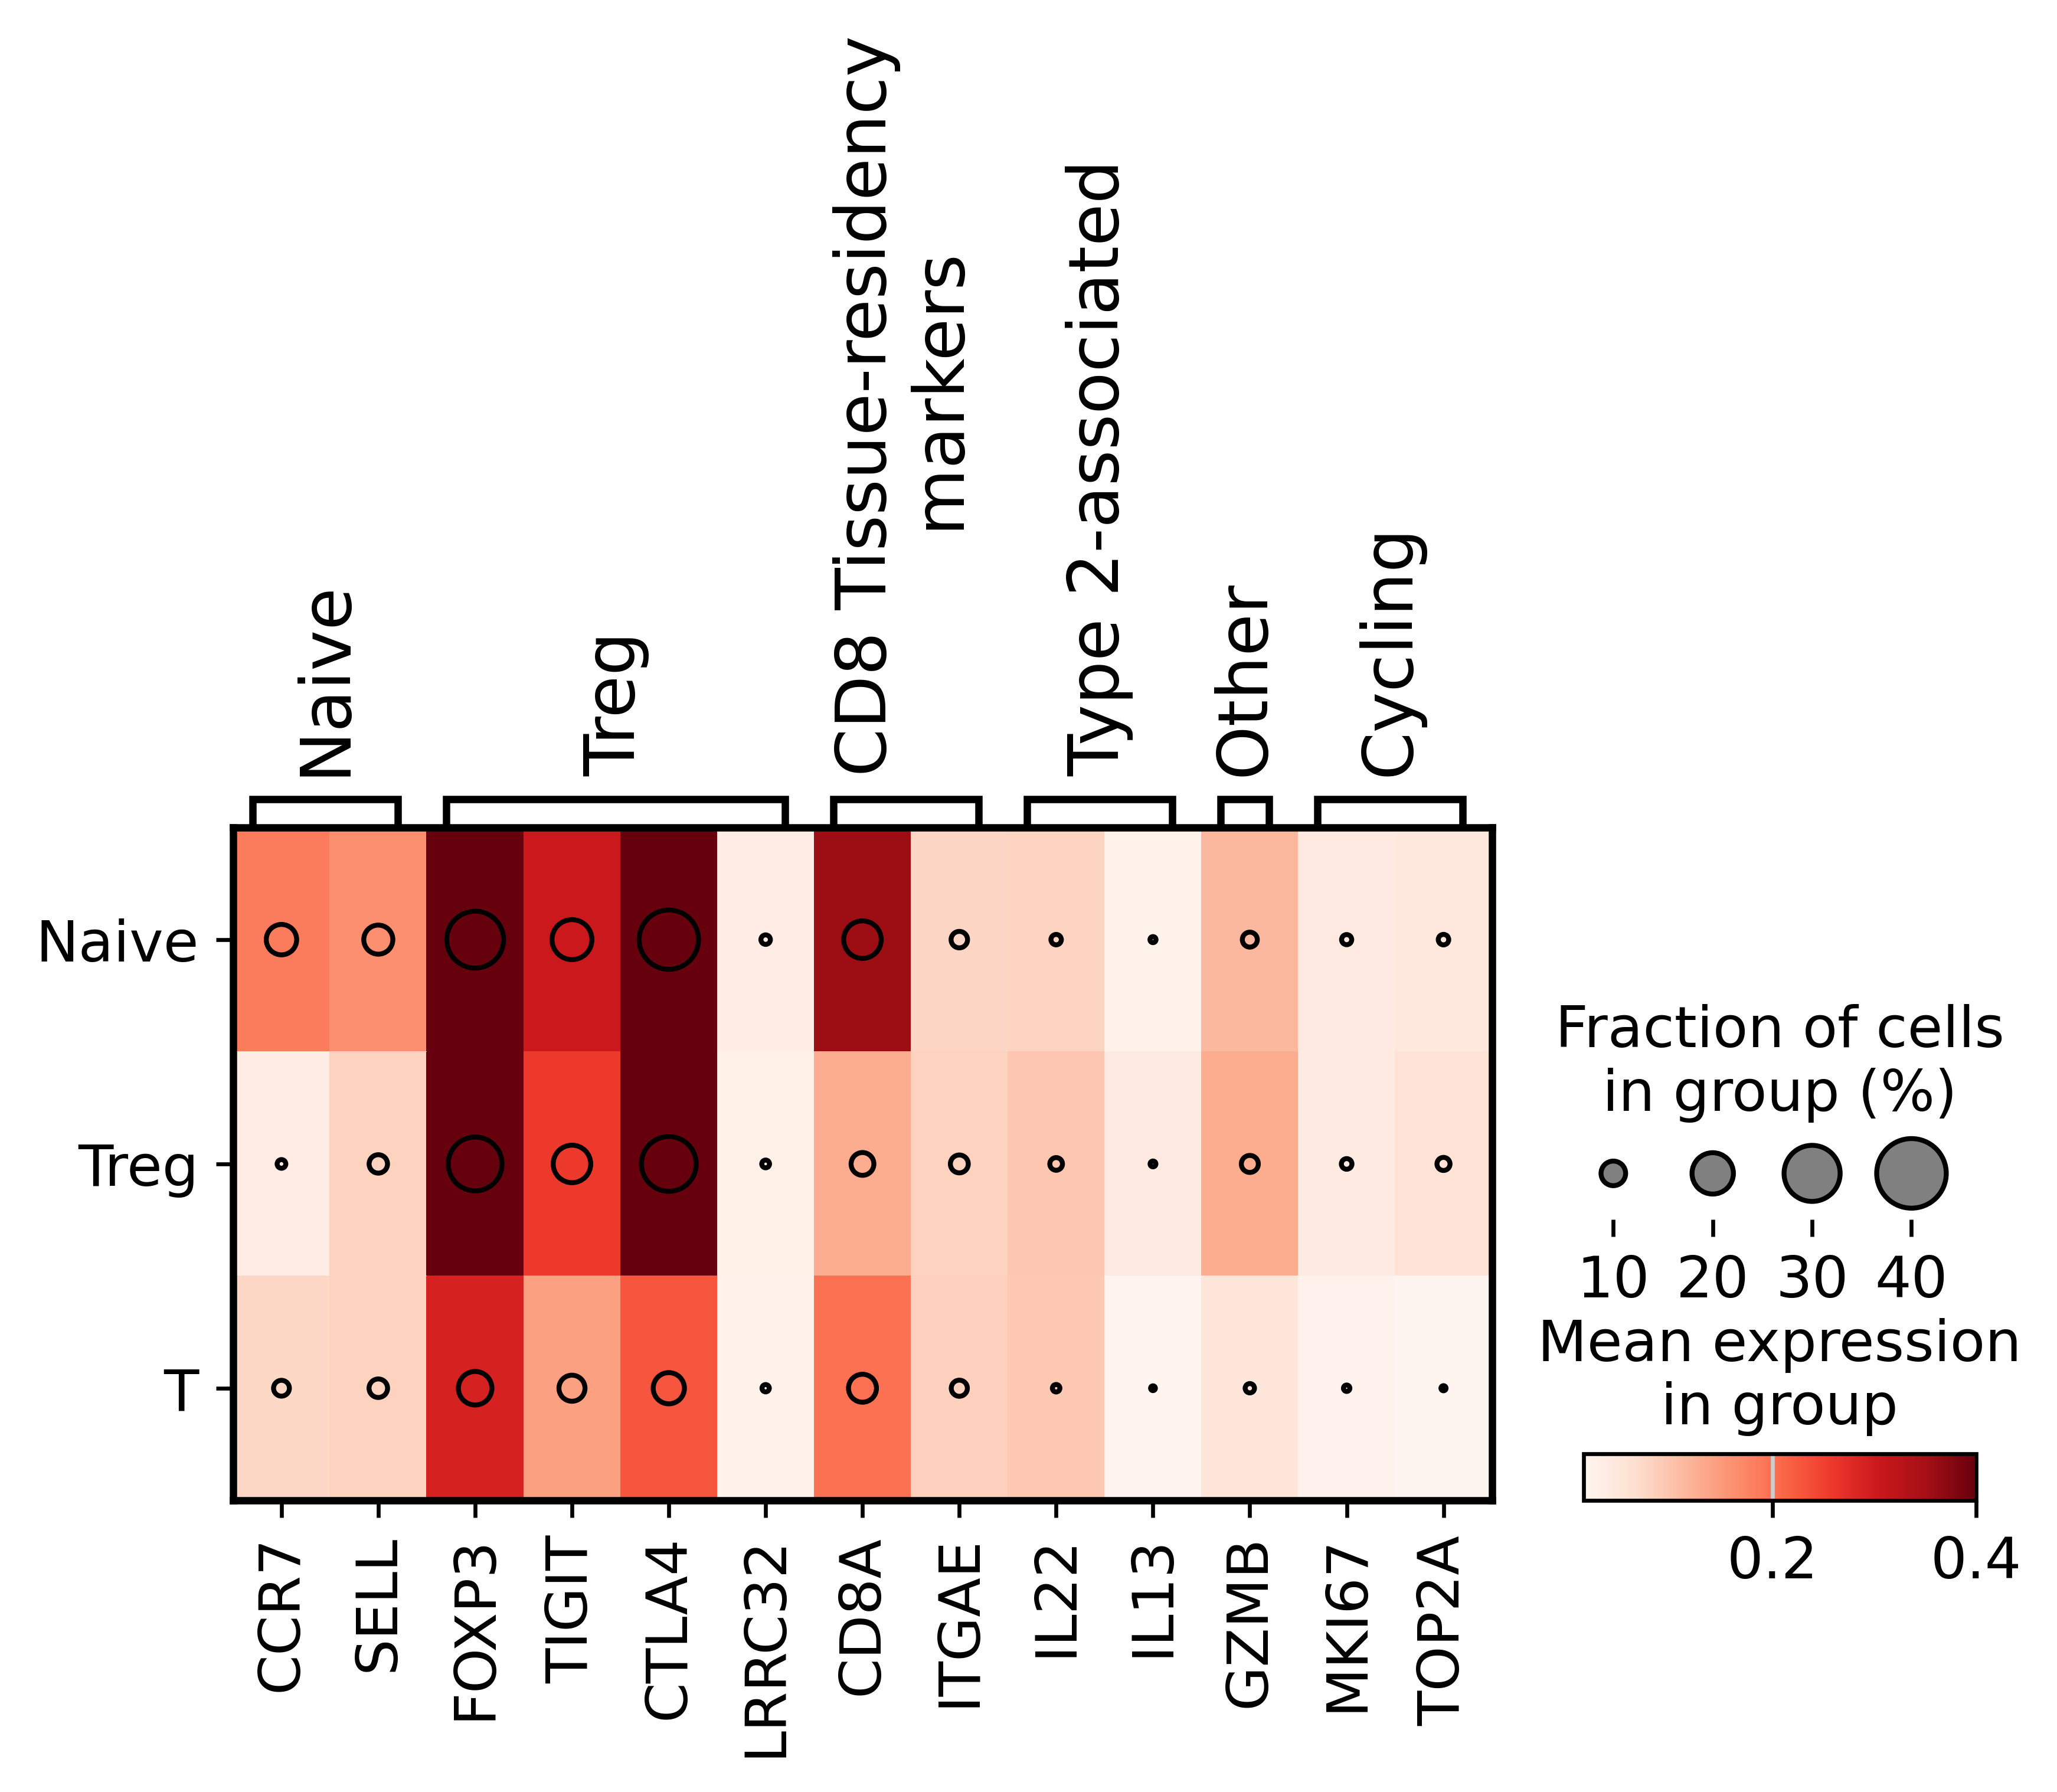

In [19]:
ORDER = ['Naive', 'Treg','T',]
fig = sc.pl.DotPlot(
    adata_all_genes[adata_all_genes.obs["Site_status"]=="Lesional"], 
    remove_markers(t_dict),
    groupby='t_intrinsic',
    vmax=0.4,
    cmap="Reds",
                 categories_order=ORDER

)
fig.style(cmap='Reds', color_on='square', dot_edge_color='black', dot_edge_lw=1, grid=True)
fig.savefig("figures/eczema_h.pdf", bbox_inches='tight')
fig.show()

In [21]:
# mapping_dict2